**Amazon User Segmentation(age vs rating)**

**Importing the dependencies**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

**Importing the dataset**

In [2]:
#loading the data
amazon_data = pd.read_csv('/content/Amazon.com cluster model.csv')

In [7]:
#reading first 5 rows
amazon_data.head()

,Cus_ID,Sex,Age,Income,Rating
0,301219,M,23,53667,150
1,301220,F,32,50420,106
2,301221,M,23,62896,10
3,301222,M,32,55306,22
4,301223,F,34,20634,117


In [4]:
X = amazon_data.iloc[:,[2,4]].values

In [5]:
print(X)

[[ 23 150]
 [ 32 106]
 [ 23  10]
 [ 32  22]
 [ 34 117]
 [ 43   6]
 [ 43 123]
 [ 22 133]
 [ 34 108]
 [ 23  62]
 [ 29 125]
 [ 28  73]
 [ 27  44]
 [ 25  66]
 [ 26  30]
 [ 38  38]
 [ 23 128]
 [ 21 130]
 [ 21  59]
 [ 22  42]
 [ 20   3]
 [ 31  30]
 [ 32  57]
 [ 33  97]
 [ 30  75]
 [ 39  16]
 [ 37   9]
 [ 35 131]
 [ 30 149]
 [ 31  48]
 [ 29  76]
 [ 28 105]
 [ 35  76]
 [ 22  54]
 [ 20 145]
 [ 23 144]
 [ 21 122]
 [ 27  71]
 [ 28 121]
 [ 23 132]
 [ 29  14]
 [ 36  34]
 [ 39 145]
 [ 31  54]
 [ 37  84]
 [ 39  61]
 [ 20  70]
 [ 29 148]
 [ 35  56]
 [ 23  84]
 [ 34  48]
 [ 34   9]
 [ 23  16]
 [ 34  55]
 [ 32  73]
 [ 23 120]
 [ 19  59]
 [ 19  41]
 [ 23   9]
 [ 24 121]
 [ 25 101]
 [ 26 128]
 [ 27   4]
 [ 28  27]
 [ 29  12]
 [ 20 130]
 [ 39 135]
 [ 38  97]
 [ 34  69]
 [ 35  47]
 [ 36  51]
 [ 37 101]
 [ 38  62]
 [ 32 113]
 [ 32 146]
 [ 20  18]
 [ 27 129]
 [ 39 113]
 [ 25  30]
 [ 26 128]
 [ 27 116]
 [ 28  30]
 [ 26  81]
 [ 25 149]
 [ 26 117]
 [ 27  23]
 [ 28  42]
 [ 25  80]
 [ 27  57]
 [ 28 136]
 [ 29  17]

**Choosing the number of clusters**

In [8]:
#finding the wcss value for different number of clusters
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init = 'k-means++',random_state=40)
  kmeans.fit(X)

  wcss.append(kmeans.inertia_)

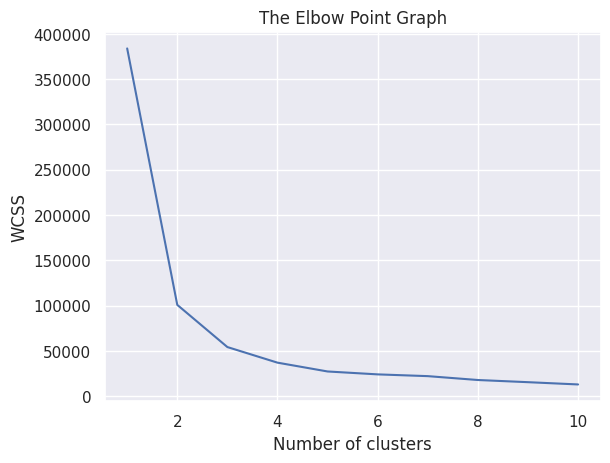

In [9]:
#plot the elbow graph
sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


Optimal number of clusters = 4

In [10]:
kmeans = KMeans(n_clusters=4, init='k-means++',random_state = 0)

#return a label for each data point based on their cluster

Y = kmeans.fit_predict(X)
print(Y)

[3 1 0 0 1 0 1 3 1 2 3 2 0 2 0 0 3 3 2 0 0 0 2 1 2 0 0 3 3 2 2 1 2 2 3 3 3
 2 1 3 0 0 3 2 2 2 2 3 2 2 2 0 0 2 2 1 2 0 0 1 1 3 0 0 0 3 3 1 2 2 2 1 2 1
 3 0 3 1 0 3 1 0 2 3 1 0 0 2 2 3 0 1 0 3 2 1 0 1 1 3 0 3 2 2 3 1 2 3 2 1 0
 1 3 2 0 2 0 1 1 1 1 0 2 2 3 1 3 0 2 1 2 2 0 2 2 1 0 2 1 0 0 1 2 2 1 0 1 2
 2 3 1 0 1 0 2 2 1 3 0 0 1 2 2 1 2 0 1 0 2 2 2 1 2 1 0 0 3 0 0 3 3 1 3 1 2
 3 0 2 1 2 1 3 0 1 0 2 3 1 2 3 2 3]


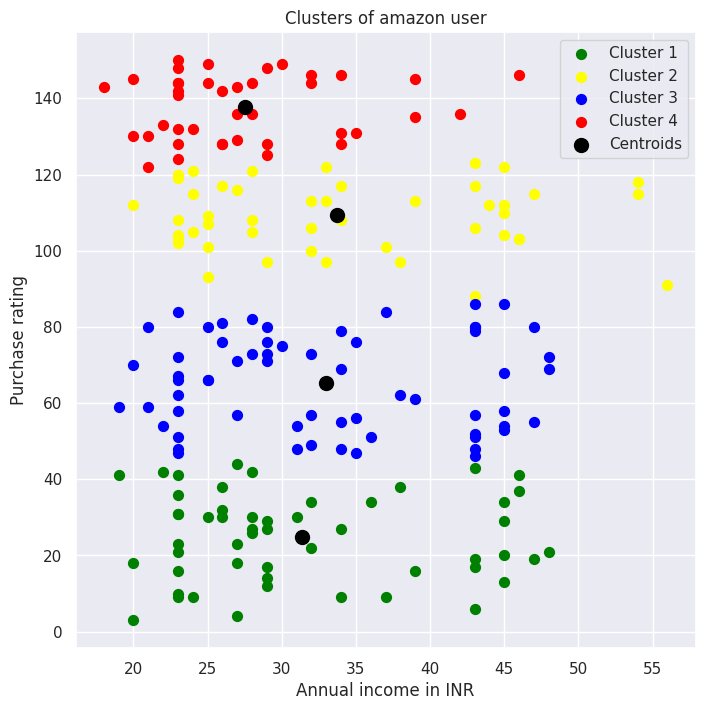

In [11]:
#ploting all the clustera and their centroids
plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='green', label='Cluster 1' )
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='yellow', label='Cluster 2' )
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='blue', label='Cluster 3' )
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='red', label='Cluster 4' )

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='Centroids')

plt.title('Clusters of amazon user')
plt.xlabel('Annual income in INR')
plt.ylabel('Purchase rating')
plt.legend()
plt.show()
